In [1]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
insurance_data = pd.read_csv("insurance.csv")

X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X = pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)

X["sex"]=X["sex"].map({"female":"1","male":"0"})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alphas 0.001 : 20922596.528006196
MSE for alphas 0.1 : 20921899.28756773
MSE for alphas 1 : 20915761.347724438
MSE for alphas 2 : 20909904.88284824
MSE for alphas 5 : 20894930.88738714
MSE for alphas 10 : 20879460.42907431
MSE for alphas 25 : 20906237.825702816
MSE for alphas 40 : 21030365.00375737
MSE for alphas 65 : 21382318.342543084
MSE for alphas 100 : 22325946.521791272


<Axes: >

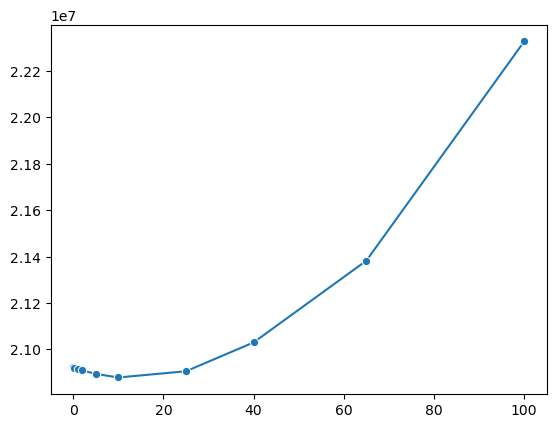

In [8]:
import seaborn as sns

alphas = [0.001,0.1,1,2,5,10,25,40,65,100]
mses = []


for a in alphas:
  lasso_model = Lasso(alpha = a)
  lasso_model.fit(X_train,y_train)

  y_pred = lasso_model.predict(X_test)
  mse = mean_squared_error(y_test,y_pred)

  print(f"MSE for alphas {a} :",mse)
  mses.append(mse)
sns.lineplot(x=alphas,y=mses, marker="o")